In [525]:
ruta_resultados = "resultados03"

import pandas as pd
import numpy as np

# --- cargar cuaterniones ---
df_q = pd.read_csv("deltas_cuat04.csv")

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
    "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
})

# Comprobar si es un valor válido
# df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# print(df_q)

df_q["time_comp"] = df_q["Time"] * 1e-8
df_q["time_comp"] = df_q["time_comp"].astype(int)
# df_q["time_comp"]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# df_u

df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1773427747770151936,0.999998,0.001999,-0.000074,0.000365,1,17734277477
1,1773427747870151936,0.999998,0.001999,-0.000066,0.000367,1,17734277478
2,1773427747970151936,0.999998,0.001998,-0.000076,0.000367,1,17734277479
3,1773427748070151936,0.999998,0.002012,-0.000068,0.000379,1,17734277480
4,1773427748170151680,0.999969,0.002177,-0.000084,0.007546,1,17734277481
...,...,...,...,...,...,...,...
150,1773427762769497088,0.999421,-0.014996,-0.001638,0.030493,1,17734277627
151,1773427762869364400,0.999442,-0.013417,-0.001450,0.030544,1,17734277628
152,1773427762969364480,0.999440,-0.011805,-0.001288,0.031283,1,17734277629
153,1773427763069364224,0.999436,-0.011018,-0.001142,0.031685,1,17734277630


In [526]:
# dt = df_q['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [527]:
# cargar aceleraciones
df_a = pd.read_csv("deltas04.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:deltaThetaX": "arx",
    "inertial-6286.188861:deltaThetaY": "ary",
    "inertial-6286.188861:deltaThetaZ": "arz",
    "inertial-6286.188861:deltaVelX": "alx",
    "inertial-6286.188861:deltaVelY": "aly",
    "inertial-6286.188861:deltaVelZ": "alz",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["arXvalid"] == 1) &
#     (df_a["arYvalid"] == 1) &
#     (df_a["arZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
# df_a["time_comp"] 

# df_a["dt"] = df_a["Time"].diff() * 1e-9

df_a

,Time,alx,aly,alz,arx,ary,arz,time_comp
0,1773427747689390592,0.000025,-0.000342,-0.099590,0.000019,-0.000022,0.000021,17734277476
1,1773427747789371392,0.000037,-0.000332,-0.099604,0.000041,-0.000020,0.000016,17734277477
2,1773427747889351936,0.000014,-0.000356,-0.099610,0.000008,0.000009,0.000007,17734277478
3,1773427747989332736,0.000025,-0.000334,-0.099595,0.000007,-0.000026,0.000005,17734277479
4,1773427748089313280,0.000039,-0.000358,-0.099616,0.000034,0.000010,0.000028,17734277480
...,...,...,...,...,...,...,...,...
151,1773427762786627840,-0.000048,0.003521,-0.099673,0.001527,-0.000054,0.000031,17734277627
152,1773427762886610432,-0.000027,0.003586,-0.099464,0.003223,-0.000105,0.000019,17734277628
153,1773427762986593024,-0.000370,0.002580,-0.099685,0.003320,-0.000140,0.001400,17734277629
154,1773427763086575616,0.000264,0.003324,-0.099516,0.001718,-0.000062,0.000728,17734277630


In [528]:
# dt = df_a['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [529]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[ 1.91515628e-05, -2.16035460e-05,  2.08090478e-05,
         2.50737303e-05, -3.41759092e-04, -9.95896310e-02],
       [ 4.10538523e-05, -2.03326636e-05,  1.60014733e-05,
         3.66786699e-05, -3.31929070e-04, -9.96035412e-02],
       [ 7.59127806e-06,  8.58245312e-06,  7.08967491e-06,
         1.36499184e-05, -3.56103003e-04, -9.96096581e-02],
       [ 6.56454858e-06, -2.63278398e-05,  5.13015357e-06,
         2.46983946e-05, -3.34456505e-04, -9.95950475e-02],
       [ 3.43810134e-05,  9.88315969e-06,  2.79991473e-05,
         3.86885586e-05, -3.57785786e-04, -9.96163040e-02],
       [ 3.54358810e-04,  1.10138753e-05,  1.43463733e-02,
        -3.10419197e-03,  1.33155799e-03, -9.97011289e-02],
       [ 3.97401024e-03, -1.82752148e-03,  5.91432268e-04,
         3.16135352e-03, -2.03158334e-03, -9.95321721e-02],
       [-2.15232093e-03,  9.24039981e-04,  2.25273031e-03,
        -9.65581930e-05, -1.30405743e-03, -9.95885879e-02],
       [ 3.25468346e-03, -1.38887984e-03, -6.945

In [530]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 10.0      # Hz
fc = 2.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.04658291  0.09316581  0.04658291  1.         -0.32897568  0.06458765]
 [ 1.          2.          1.          1.         -0.45311952  0.46632557]]


array([[ 8.92135462e-07, -1.00635597e-06,  9.69345930e-07,
         1.16800724e-06, -1.59201319e-05, -4.63917448e-03],
       [ 6.17868448e-06, -5.75964460e-06,  5.38089966e-06,
         7.29412085e-06, -9.15938072e-05, -2.68247965e-02],
       [ 1.75817542e-05, -1.32472484e-05,  1.26771552e-05,
         1.93887696e-05, -2.34767717e-04, -6.88594496e-02],
       [ 2.64754836e-05, -1.59636076e-05,  1.63426846e-05,
         2.90349423e-05, -3.62624164e-04, -1.06057313e-01],
       [ 2.33412186e-05, -1.13405767e-05,  1.33077698e-05,
         2.90432598e-05, -3.96507496e-04, -1.15121713e-01],
       [ 3.13529698e-05, -4.61290889e-06,  6.78462194e-04,
        -1.19944611e-04, -2.83591794e-04, -1.03933308e-01],
       [ 2.75291778e-04, -8.32361813e-05,  3.23402217e-03,
        -5.23929692e-04, -3.67849199e-05, -9.45598608e-02],
       [ 9.43428365e-04, -3.57339895e-04,  6.30028424e-03,
        -5.98464239e-04, -4.68181597e-05, -9.53704302e-02],
       [ 1.48460537e-03, -6.24171244e-04,  6.079

In [531]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 2  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([ 1.90624173e-05, -9.07869188e-04, -4.05747072e-04,  1.32435046e-03,
        1.94425040e-03, -5.27682380e-04, -3.35781839e-03,  5.71554035e-04,
        1.38260090e-02,  2.63202661e-02,  2.26382632e-02,  6.85286912e-04,
       -2.24145237e-02, -2.80378701e-02, -1.58193005e-02, -8.92975538e-04,
        4.75998197e-03,  2.18142393e-03, -1.21412717e-03, -1.52605605e-03,
       -9.86618928e-05,  6.88084185e-04,  3.77454532e-04, -1.29435968e-04,
       -2.13926345e-04, -2.16515377e-05,  9.24886470e-05,  4.32455504e-05,
       -3.62657643e-05, -4.85677512e-05, -1.77256245e-05, -7.74053725e-07,
       -7.02464294e-06, -9.45927762e-06,  6.61797296e-06,  2.57572290e-05,
        2.42649850e-05,  2.77657056e-06, -7.12135748e-06,  1.79036479e-05,
        4.33177722e-05, -1.10565945e-06, -1.07455126e-04, -1.24931947e-04,
        7.40685755e-05,  2.98010546e-04,  7.08976770e-05, -7.81679520e-04,
       -1.67491570e-03, -1.81669066e-03, -1.21697006e-03, -5.58844048e-04,
        2.30894622e-06,  

In [532]:
arx

array([ 1.91515628e-05,  4.10538523e-05,  7.59127806e-06,  6.56454858e-06,
        3.43810134e-05,  3.54358810e-04,  3.97401024e-03, -2.15232093e-03,
        3.25468346e-03,  2.64742561e-02,  3.71098481e-02,  4.14179033e-03,
       -3.93991396e-02, -3.10801212e-02, -2.79951422e-03,  1.76596426e-04,
        1.85909983e-07,  2.80721288e-05, -2.45310889e-06,  2.62653384e-06,
        2.06798904e-05,  3.70518537e-05,  2.56784824e-05, -3.30206876e-06,
        2.10614944e-05,  2.91616579e-05,  1.10300361e-05, -4.07937514e-05,
       -1.61046173e-05, -1.11972540e-05,  2.56692215e-06, -1.66631453e-05,
       -3.75547679e-05,  1.65053407e-05,  1.02884160e-05,  2.08234974e-06,
        3.41036575e-05,  2.99355706e-05, -2.08014280e-05,  1.63813402e-05,
       -1.29872396e-05,  1.59134524e-05, -3.75426280e-05, -1.91893650e-05,
       -2.81422235e-05, -3.22424748e-05,  3.93648370e-05,  1.18418802e-05,
       -1.04889181e-03, -4.56624851e-03, -8.02439463e-05,  1.90047408e-03,
       -3.56791378e-03,  

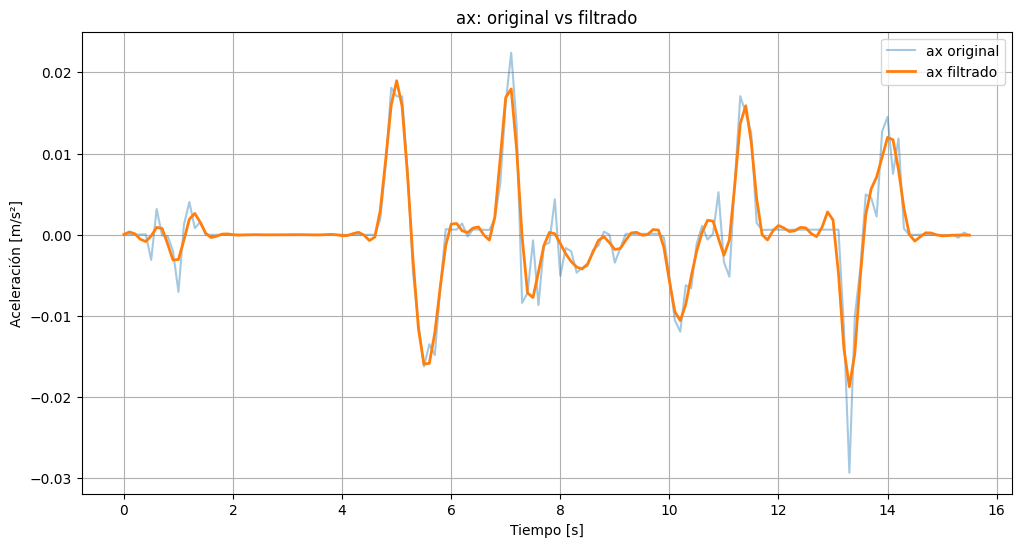

In [533]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

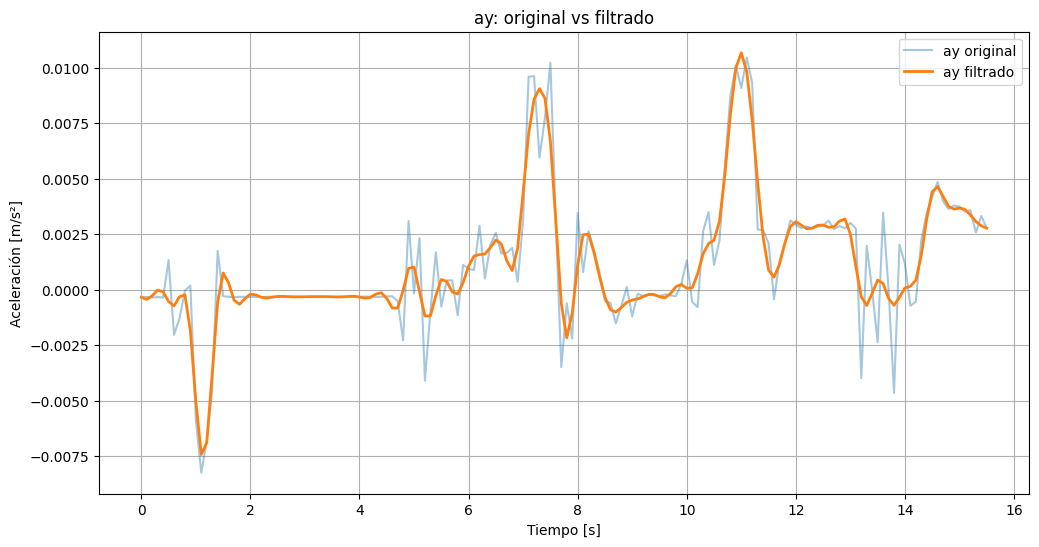

In [534]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(aly)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, aly, label='ay original', alpha=0.4)
plt.plot(t, aly_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ay: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

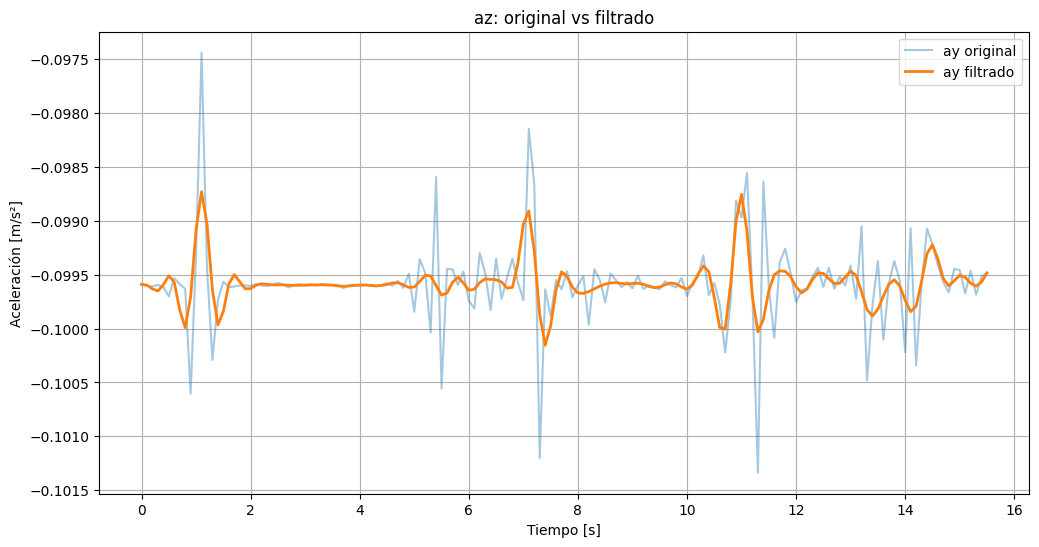

In [535]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alz)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alz, label='ay original', alpha=0.4)
plt.plot(t, alz_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("az: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [536]:
print(alx_f.shape)
df_a['arx']

(156,)


0      0.000019
1      0.000041
2      0.000008
3      0.000007
4      0.000034
         ...   
151    0.001527
152    0.003223
153    0.003320
154    0.001718
155    0.001480
Name: arx, Length: 156, dtype: float64

In [537]:
# print(arx_f.shape)
# df_a['arx']
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,alx,aly,alz,arx,ary,arz,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773427747689390592,0.000025,-0.000342,-0.099590,0.000019,-0.000022,0.000021,17734277476,0.000019,-0.000022,0.000021,0.000025,-0.000342,-0.099590
1,1773427747789371392,0.000037,-0.000332,-0.099604,0.000041,-0.000020,0.000016,17734277477,-0.000908,0.000012,-0.001409,0.000336,-0.000439,-0.099598
2,1773427747889351936,0.000014,-0.000356,-0.099610,0.000008,0.000009,0.000007,17734277478,-0.000406,0.000042,-0.001408,0.000109,-0.000278,-0.099632
3,1773427747989332736,0.000025,-0.000334,-0.099595,0.000007,-0.000026,0.000005,17734277479,0.001324,0.000013,0.001195,-0.000552,-0.000019,-0.099651
4,1773427748089313280,0.000039,-0.000358,-0.099616,0.000034,0.000010,0.000028,17734277480,0.001944,-0.000125,0.005367,-0.000845,-0.000096,-0.099593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1773427762786627840,-0.000048,0.003521,-0.099673,0.001527,-0.000054,0.000031,17734277627,0.001377,-0.000055,-0.000015,-0.000114,0.003617,-0.099523
152,1773427762886610432,-0.000027,0.003586,-0.099464,0.003223,-0.000105,0.000019,17734277628,0.002869,-0.000104,0.000312,-0.000064,0.003368,-0.099580
153,1773427762986593024,-0.000370,0.002580,-0.099685,0.003320,-0.000140,0.001400,17734277629,0.003248,-0.000121,0.000843,-0.000045,0.003074,-0.099606
154,1773427763086575616,0.000264,0.003324,-0.099516,0.001718,-0.000062,0.000728,17734277630,0.002589,-0.000088,0.000793,-0.000047,0.002875,-0.099568


In [538]:
df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1773427747770151936,0.999998,0.001999,-0.000074,0.000365,1,17734277477
1,1773427747870151936,0.999998,0.001999,-0.000066,0.000367,1,17734277478
2,1773427747970151936,0.999998,0.001998,-0.000076,0.000367,1,17734277479
3,1773427748070151936,0.999998,0.002012,-0.000068,0.000379,1,17734277480
4,1773427748170151680,0.999969,0.002177,-0.000084,0.007546,1,17734277481
...,...,...,...,...,...,...,...
150,1773427762769497088,0.999421,-0.014996,-0.001638,0.030493,1,17734277627
151,1773427762869364400,0.999442,-0.013417,-0.001450,0.030544,1,17734277628
152,1773427762969364480,0.999440,-0.011805,-0.001288,0.031283,1,17734277629
153,1773427763069364224,0.999436,-0.011018,-0.001142,0.031685,1,17734277630


In [539]:
df_a

,Time,alx,aly,alz,arx,ary,arz,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773427747689390592,0.000025,-0.000342,-0.099590,0.000019,-0.000022,0.000021,17734277476,0.000019,-0.000022,0.000021,0.000025,-0.000342,-0.099590
1,1773427747789371392,0.000037,-0.000332,-0.099604,0.000041,-0.000020,0.000016,17734277477,-0.000908,0.000012,-0.001409,0.000336,-0.000439,-0.099598
2,1773427747889351936,0.000014,-0.000356,-0.099610,0.000008,0.000009,0.000007,17734277478,-0.000406,0.000042,-0.001408,0.000109,-0.000278,-0.099632
3,1773427747989332736,0.000025,-0.000334,-0.099595,0.000007,-0.000026,0.000005,17734277479,0.001324,0.000013,0.001195,-0.000552,-0.000019,-0.099651
4,1773427748089313280,0.000039,-0.000358,-0.099616,0.000034,0.000010,0.000028,17734277480,0.001944,-0.000125,0.005367,-0.000845,-0.000096,-0.099593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1773427762786627840,-0.000048,0.003521,-0.099673,0.001527,-0.000054,0.000031,17734277627,0.001377,-0.000055,-0.000015,-0.000114,0.003617,-0.099523
152,1773427762886610432,-0.000027,0.003586,-0.099464,0.003223,-0.000105,0.000019,17734277628,0.002869,-0.000104,0.000312,-0.000064,0.003368,-0.099580
153,1773427762986593024,-0.000370,0.002580,-0.099685,0.003320,-0.000140,0.001400,17734277629,0.003248,-0.000121,0.000843,-0.000045,0.003074,-0.099606
154,1773427763086575616,0.000264,0.003324,-0.099516,0.001718,-0.000062,0.000728,17734277630,0.002589,-0.000088,0.000793,-0.000047,0.002875,-0.099568


In [540]:
df_u = pd.merge(
    df_q,
    df_a,
    on="time_comp",
    how="inner"
)
df_u

,Time_x,q0,q1,q2,q3,qValid,time_comp,Time_y,alx,aly,alz,arx,ary,arz,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773427747770151936,0.999998,0.001999,-0.000074,0.000365,1,17734277477,1773427747789371392,0.000037,-0.000332,-0.099604,0.000041,-0.000020,0.000016,-0.000908,0.000012,-0.001409,0.000336,-0.000439,-0.099598
1,1773427747870151936,0.999998,0.001999,-0.000066,0.000367,1,17734277478,1773427747889351936,0.000014,-0.000356,-0.099610,0.000008,0.000009,0.000007,-0.000406,0.000042,-0.001408,0.000109,-0.000278,-0.099632
2,1773427747970151936,0.999998,0.001998,-0.000076,0.000367,1,17734277479,1773427747989332736,0.000025,-0.000334,-0.099595,0.000007,-0.000026,0.000005,0.001324,0.000013,0.001195,-0.000552,-0.000019,-0.099651
3,1773427748070151936,0.999998,0.002012,-0.000068,0.000379,1,17734277480,1773427748089313280,0.000039,-0.000358,-0.099616,0.000034,0.000010,0.000028,0.001944,-0.000125,0.005367,-0.000845,-0.000096,-0.099593
4,1773427748170151680,0.999969,0.002177,-0.000084,0.007546,1,17734277481,1773427748189293824,-0.003104,0.001332,-0.099701,0.000354,0.000011,0.014346,-0.000528,-0.000334,0.007219,-0.000149,-0.000538,-0.099510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1773427762769497088,0.999421,-0.014996,-0.001638,0.030493,1,17734277627,1773427762786627840,-0.000048,0.003521,-0.099673,0.001527,-0.000054,0.000031,0.001377,-0.000055,-0.000015,-0.000114,0.003617,-0.099523
151,1773427762869364400,0.999442,-0.013417,-0.001450,0.030544,1,17734277628,1773427762886610432,-0.000027,0.003586,-0.099464,0.003223,-0.000105,0.000019,0.002869,-0.000104,0.000312,-0.000064,0.003368,-0.099580
152,1773427762969364480,0.999440,-0.011805,-0.001288,0.031283,1,17734277629,1773427762986593024,-0.000370,0.002580,-0.099685,0.003320,-0.000140,0.001400,0.003248,-0.000121,0.000843,-0.000045,0.003074,-0.099606
153,1773427763069364224,0.999436,-0.011018,-0.001142,0.031685,1,17734277630,1773427763086575616,0.000264,0.003324,-0.099516,0.001718,-0.000062,0.000728,0.002589,-0.000088,0.000793,-0.000047,0.002875,-0.099568


In [541]:
df_u = df_u.rename(columns={"Time_x": "time"})
df_u.drop(["Time_y"], axis=1, inplace=True)
# df_u

df_u["dt"] = df_u["time"].diff() * 1e-9
# df_u

new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt', 'arx_f', 'ary_f', 'arz_f', 'alx_f', 'aly_f', 'alz_f']
df_u = df_u[new_order]
# print(df_u)
df_u

,time,q0,q1,q2,q3,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773427747770151936,0.999998,0.001999,-0.000074,0.000365,0.000041,-0.000020,0.000016,0.000037,-0.000332,-0.099604,NaN,-0.000908,0.000012,-0.001409,0.000336,-0.000439,-0.099598
1,1773427747870151936,0.999998,0.001999,-0.000066,0.000367,0.000008,0.000009,0.000007,0.000014,-0.000356,-0.099610,0.100000,-0.000406,0.000042,-0.001408,0.000109,-0.000278,-0.099632
2,1773427747970151936,0.999998,0.001998,-0.000076,0.000367,0.000007,-0.000026,0.000005,0.000025,-0.000334,-0.099595,0.100000,0.001324,0.000013,0.001195,-0.000552,-0.000019,-0.099651
3,1773427748070151936,0.999998,0.002012,-0.000068,0.000379,0.000034,0.000010,0.000028,0.000039,-0.000358,-0.099616,0.100000,0.001944,-0.000125,0.005367,-0.000845,-0.000096,-0.099593
4,1773427748170151680,0.999969,0.002177,-0.000084,0.007546,0.000354,0.000011,0.014346,-0.003104,0.001332,-0.099701,0.100000,-0.000528,-0.000334,0.007219,-0.000149,-0.000538,-0.099510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1773427762769497088,0.999421,-0.014996,-0.001638,0.030493,0.001527,-0.000054,0.000031,-0.000048,0.003521,-0.099673,0.100000,0.001377,-0.000055,-0.000015,-0.000114,0.003617,-0.099523
151,1773427762869364400,0.999442,-0.013417,-0.001450,0.030544,0.003223,-0.000105,0.000019,-0.000027,0.003586,-0.099464,0.099867,0.002869,-0.000104,0.000312,-0.000064,0.003368,-0.099580
152,1773427762969364480,0.999440,-0.011805,-0.001288,0.031283,0.003320,-0.000140,0.001400,-0.000370,0.002580,-0.099685,0.100000,0.003248,-0.000121,0.000843,-0.000045,0.003074,-0.099606
153,1773427763069364224,0.999436,-0.011018,-0.001142,0.031685,0.001718,-0.000062,0.000728,0.000264,0.003324,-0.099516,0.100000,0.002589,-0.000088,0.000793,-0.000047,0.002875,-0.099568


In [542]:
# solo como comprobación

import numpy as np

dt = df_u['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 10.000511361212627 Hz


In [543]:
# import numpy as np

# # Inicializar columnas
# for col in ["vx", "vy", "vz", "px", "py", "pz"]:
#     df_u[col] = 0.0

# p = np.zeros(3)
# v = np.ones(3)

# # Umbrales
# ACC_TH = 0.1       # m/s^2
# GYRO_TH = np.deg2rad(1.0)  # rad/s

# print(v.shape)
# print(df_u.loc[k, ["vx", "vy", "vz"]].shape)
# # len(df_a)

# a = df_u.loc[2, ["alx", "aly", "alz"]].values
# a.shape

# v.shape
# dt = 0.01
# # np.zeros(3).shape

# a = df_u.loc[2, ["alx", "aly", "alz"]].values.copy()
# print(type(a), a.shape)
# a[1] = 0.0
# print(a[1], a.flags)

# arr_1d = np.array([1, 2, 3, 4, 5])
# print(arr_1d.shape)
# arr_1d[2] = 99  # Modifies the third element (index 2)
# print(arr_1d)


# print(v, v.shape)
# v[1] = 0
# print(v, v.shape)

# x = v + a#*dt
# x

In [544]:
# a = df_a.loc[3, ["alx", "aly", "alz"]].values
# a

In [545]:
# def zupt_acc_ang(a, g, v):
#     if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
#         v = np.zeros(3)   # ZUPT duro

In [546]:
# ACC_TH_ENERGY = (0.02**2)*3 # = 0.0012

Threshold alx_f: 0.017706454877507855


Threshold aly_f: 0.009292054945883432
Threshold alz_f: -0.0989856379901384
Threshold norm(alx_f,aly_f): 0.018811085201639714
Threshold norm(alx_f,alz_f): 0.10104469238264886
Threshold norm(aly_f,alz_f): 0.10016787988890141
Threshold norm(alx_f,aly_f,alz_f): 0.10106942994803081


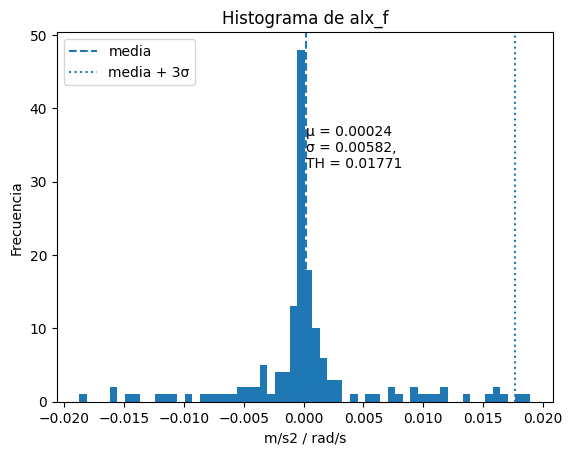

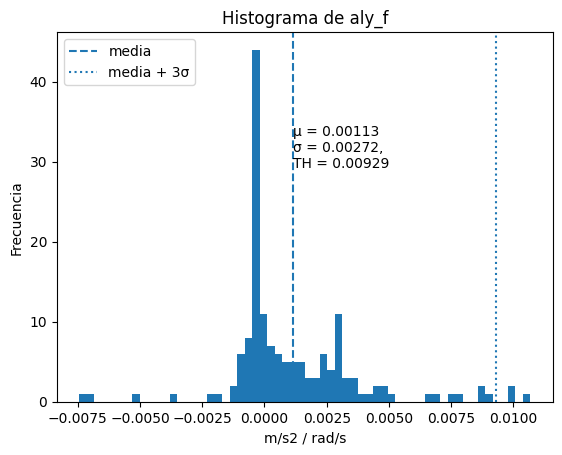

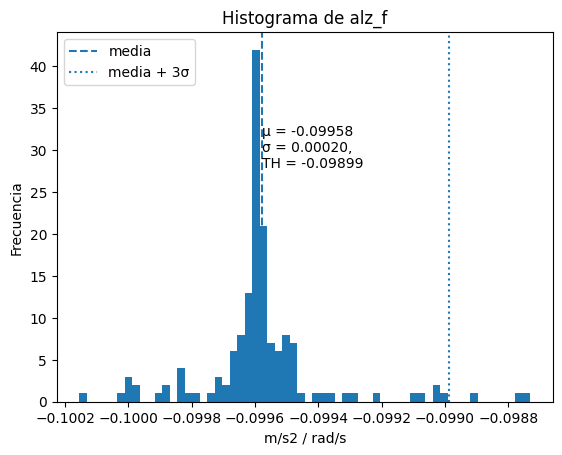

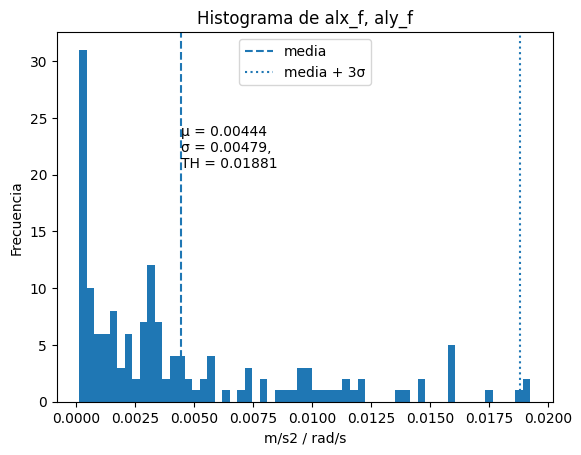

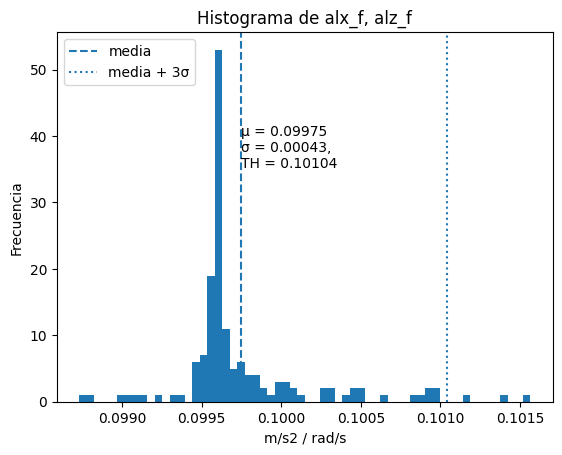

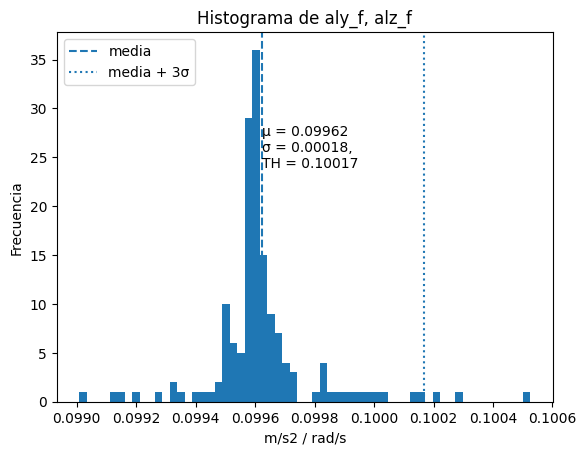

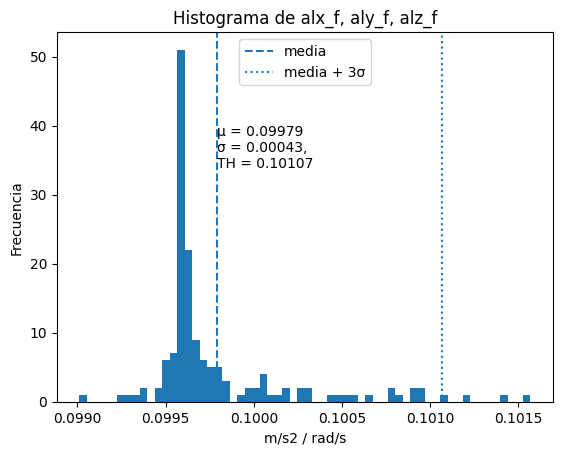

In [547]:
# σ describe ruido + vibración

# segun prueba obtener umbrales y ganancias
import numpy as np
import matplotlib.pyplot as plt

# accl = df_u[["alx_f", "aly_f", "alz_f"]].values#.copy()
# print(accl)
# gyro = df_u[["arx_f", "ary_f", "arz_f"]].values

def histogramaUnEje(axis):
    axis_values = df_u[axis].values
    # axis_values = np.linalg.norm(axis_values)

    axis_mean  = np.mean(axis_values)
    axis_std   = np.std(axis_values)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_values, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis}")
    plt.legend()

    print(f"Threshold {axis}: {th_value}")

def histogramaDosEjes(axis1, axis2):
    axis_values = df_u[[axis1, axis2]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}")
    plt.legend()

    print(f"Threshold norm({axis1},{axis2}): {th_value}")

def histogramaTresEjes(axis1, axis2, axis3):
    axis_values = df_u[[axis1, axis2, axis3]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}, {axis3}")
    plt.legend()
    
    print(f"Threshold norm({axis1},{axis2},{axis3}): {th_value}")

histogramaUnEje("alx_f")
histogramaUnEje("aly_f")
histogramaUnEje("alz_f")
histogramaDosEjes("alx_f", "aly_f")
histogramaDosEjes("alx_f", "alz_f")
histogramaDosEjes("aly_f", "alz_f")
histogramaTresEjes("alx_f", "aly_f", "alz_f")

Threshold arx_f: 0.017926574065821578
Threshold ary_f: 0.0034924446052595304
Threshold arz_f: 0.15003396494805993
Threshold norm(arx_f,ary_f): 0.01880978110359279
Threshold norm(arx_f,arz_f): 0.15649566778256963
Threshold norm(ary_f,arz_f): 0.15604357800197344
Threshold norm(arx_f,ary_f,arz_f): 0.15653463951739996


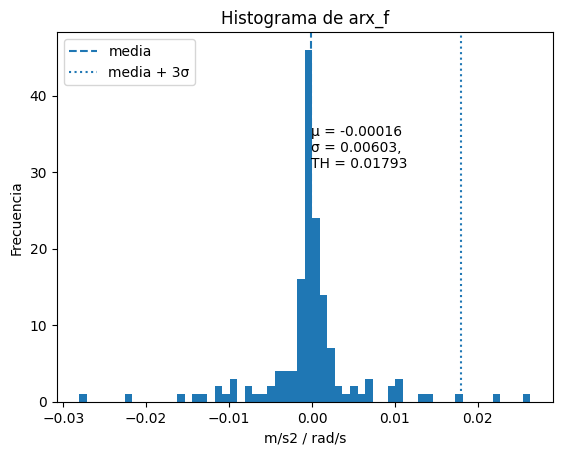

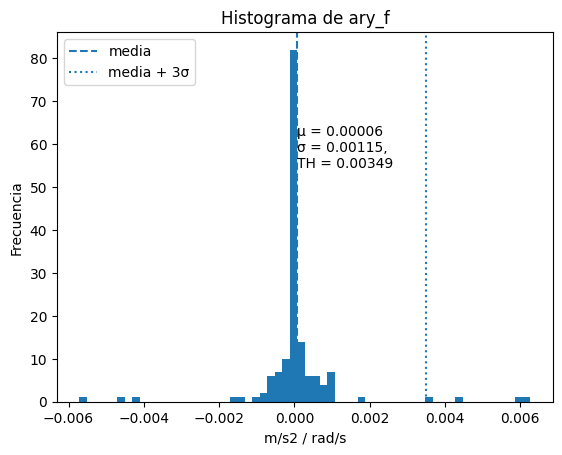

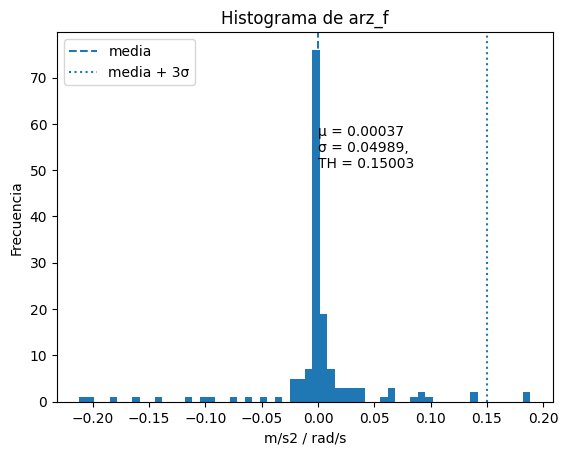

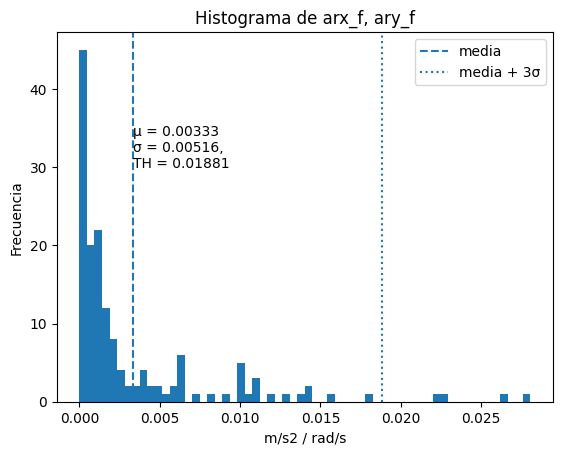

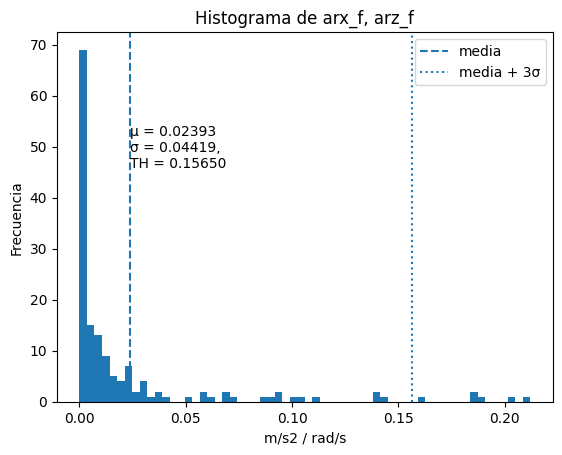

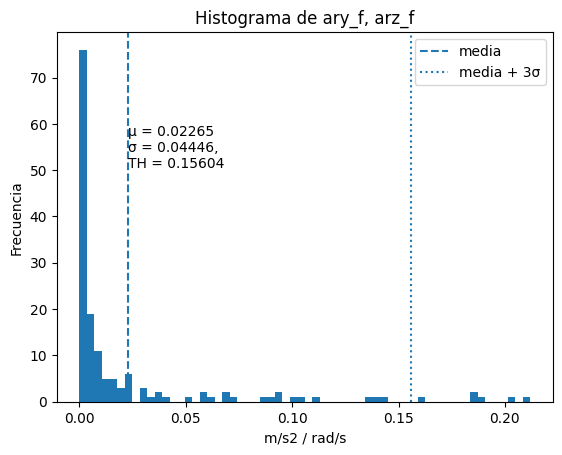

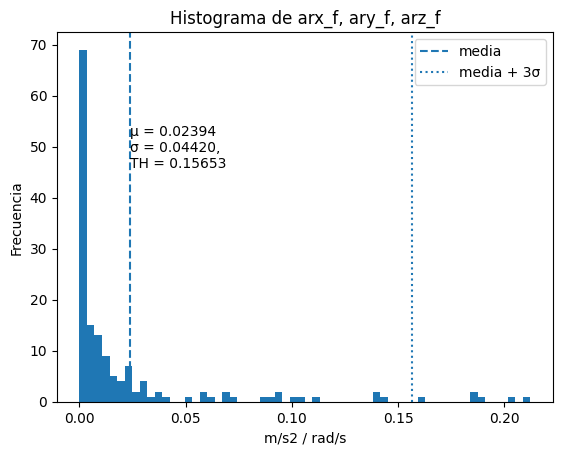

In [548]:
histogramaUnEje("arx_f")
histogramaUnEje("ary_f")
histogramaUnEje("arz_f")
histogramaDosEjes("arx_f", "ary_f")
histogramaDosEjes("arx_f", "arz_f")
histogramaDosEjes("ary_f", "arz_f")
histogramaTresEjes("arx_f", "ary_f", "arz_f")

In [549]:
"""ACC_TH   = 0.15          # m/s²
GYRO_TH  = np.deg2rad(1)

K_zupt   = 0.5
K_nhc_y  = 0.8
K_nhc_z  = 0.9

G_acc    = 0.8
G_gyro   = 1.0"""

'ACC_TH   = 0.15          # m/s²\nGYRO_TH  = np.deg2rad(1)\n\nK_zupt   = 0.5\nK_nhc_y  = 0.8\nK_nhc_z  = 0.9\n\nG_acc    = 0.8\nG_gyro   = 1.0'

In [550]:
# x1 = 2.5
# x0 = 0.5
# x = 1 / (1+((np.e)**-(1*(x-x))))
# x

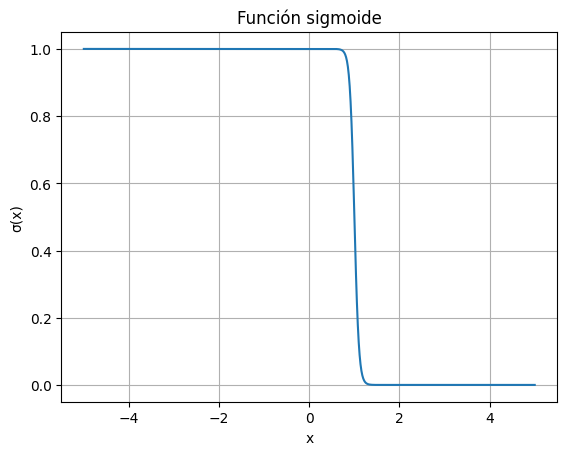

In [551]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    # k = 10 # que tan rápido crece la transición, espacio entre rangos
    # x0 = 0.5 # punto de activación - umbral # control de reposo
    valor_min = 0
    valor_max = 1
    # s = 1 / (1 + np.exp(-k*(x-x0)))
    # z = 1 / (1 + np.exp(k * (x - x0)))
    # z = np.clip(z, 0, 60)  # evita overflow

    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)  # evita overflow
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

x = np.linspace(-5, 5, 1000)
y = sigmoid_k(x)

plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Función sigmoide")
plt.grid(True)
plt.show()

# Criterio de eleccion de ruido
# ACC_TH  ≈ 3σ_acc
# GYRO_TH ≈ 3σ_gyro

In [552]:
pruebinia = sigmoid_k(0.527151, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=10.0)
pruebinia

np.float64(0.9912376484362222)

In [553]:
y = 1 / (1+((np.e)**-2.5))
y

0.9241418199787566

In [554]:
# G_acc ≈ 1.0 en recta

# G_acc ≈ 0.7 si vibra mucho

# G_acc ≈ 0.3 si hay mucho ruido

In [555]:
# from scipy.spatial.transform import Rotation as R

# def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
#     valor_min = 0
#     valor_max = 1
#     z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
#     z = np.clip(z, -10, 10)
#     z = 1 / (1 + np.exp(z))
#     return valor_min + (valor_max - valor_min) * z

#     """ 
#     G_acc = 0.8   # 1 = full confianza
#     G_gyro = 1.0

#     # Umbrales de ZUPT
#     ACC_TH = 0.269
#     GYRO_TH = 0.0172

#     K_zupt = 0.5

#     # # restricciones vehículo
#     K_nhc_y = 0.2   # lateral
#     K_nhc_z = 0.1   # vertical
#     """

# def ins(df=df_u,
#         G_acc=1.0,
#         G_gyro=1.0,
#         p_gain=1.0,
#         ACC_TH=0.0732, # ACC_TH=0.269,
#         GYRO_TH=0.0112, # GYRO_TH=0.0172,
#         ZUPT_GAIN=0.5,
#         ZUPT_X0=1.0,
#         ZUPT_SIGMOID_GAIN=1.0,
#         K_nhc_y=0.9,
#         K_nhc_z=0.9,
#         dt = 0.01):

#     p = np.zeros(3)
#     p_scale = np.zeros(3)
#     v = np.zeros(3)
#     v_body = np.zeros(3)

#     for k in range(0, len(df)):

#         if pd.isna(dt):
#             continue

#         a_body = df.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
#         g = df.loc[k, ["arx_f", "ary_f", "arz_f"]].values

#         gyro_gain = np.linalg.norm(G_gyro * g)

#         q = df.loc[k, ["q0", "q1", "q2", "q3"]].values
#         # 1) Normalizar cuaternión
#         q = q / np.linalg.norm(q)

#         # 2) Rotación body → inercial
#         r = R.from_quat([q[1], q[2], q[3], q[0]])
#         R_nb = r.as_matrix().T   # body → nav

#         # 3) Aceleración en marco inercial
#         a_nav = G_acc * (R_nb @ a_body)

#         df.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

#         # Velocidad
#         v = v + a_nav * dt

#         v = v + R_nb @ delta_v + g_nav * dt # g_nav ¿

#         df.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

#         acc_norm  = np.linalg.norm(a_body)
#         gyro_norm = np.linalg.norm(gyro_gain)

#         s_acc  = acc_norm  / ACC_TH
#         s_gyro = gyro_norm / GYRO_TH

#         zupt_score = max(s_acc, s_gyro)

#         df.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score

#         # w_zupt = smooth_step(zupt_score)
#         w_zupt = sigmoid_k(zupt_score, ZUPT_X0, ZUPT_SIGMOID_GAIN)
#         # w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

#         v -= ZUPT_GAIN * w_zupt * v

#         # velocidad en body frame
#         v_body = R_nb.T @ v

#         v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
#         v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)

#         df.loc[k, ["v_nhc_x", "v_nhc_y", "v_nhc_z"]] = v_body

#         # volver a nav
#         v = R_nb @ v_body

#         # Posición
#         p = p + v * dt

#         df.loc[k, ["vx", "vy", "vz"]] = v
#         df.loc[k, ["px", "py", "pz"]] = p
#         df.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale
        
#     print(df)
#     # df_u

In [556]:
# ins()

In [557]:
# import numpy as np
# import pandas as pd

# ###############################################
# # Utilidades matemáticas
# ###############################################

# def skew(v):
#     """Matriz skew-symmetric"""
#     return np.array([
#         [0, -v[2], v[1]],
#         [v[2], 0, -v[0]],
#         [-v[1], v[0], 0]
#     ])

# def quat_normalize(q):
#     return q / np.linalg.norm(q)

# def quat_multiply(q1, q2):
#     """Multiplicación de cuaterniones"""
#     w1,x1,y1,z1 = q1
#     w2,x2,y2,z2 = q2

#     return np.array([
#         w1*w2 - x1*x2 - y1*y2 - z1*z2,
#         w1*x2 + x1*w2 + y1*z2 - z1*y2,
#         w1*y2 - x1*z2 + y1*w2 + z1*x2,
#         w1*z2 + x1*y2 - y1*x2 + z1*w2
#     ])

# def quat_to_rot(q):
#     """Cuaternión → matriz de rotación"""
#     w,x,y,z = q

#     return np.array([
#         [1-2*(y*y+z*z), 2*(x*y-z*w), 2*(x*z+y*w)],
#         [2*(x*y+z*w), 1-2*(x*x+z*z), 2*(y*z-x*w)],
#         [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x*x+y*y)]
#     ])

# ###############################################
# # Incremental quaternion
# ###############################################

# def delta_theta_to_quat(dtheta):
#     theta = np.linalg.norm(dtheta)

#     if theta < 1e-12:
#         return np.array([1,0,0,0])

#     axis = dtheta/theta

#     w = np.cos(theta/2)
#     xyz = axis*np.sin(theta/2)

#     return np.array([w, xyz[0], xyz[1], xyz[2]])

# ###############################################
# # Coning correction
# ###############################################

# def coning(dtheta1, dtheta2):
#     return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

# ###############################################
# # Sculling correction
# ###############################################

# def sculling(dtheta1, dtheta2, dv1, dv2):

#     term = 0.5*(np.cross(dtheta1,dv2) +
#                 np.cross(dv1,dtheta2))

#     return dv1 + dv2 + term

# ###############################################
# # ZUPT detector simple
# ###############################################

# def zupt_detector(acc_norm, gyro_norm,
#                   acc_th=0.2, gyro_th=0.02):

#     if acc_norm < acc_th and gyro_norm < gyro_th:
#         return True

#     return False

# ###############################################
# # Clase INS Strapdown
# ###############################################

# class StrapdownINS:

#     def __init__(self, dt):

#         self.dt = dt

#         # estado
#         self.q = np.array([1,0,0,0])
#         self.v = np.zeros(3)
#         self.p = np.zeros(3)

#         # gravedad
#         self.g = np.array([0,0,-9.81])

#         # buffers para coning/sculling
#         self.prev_dtheta = np.zeros(3)
#         self.prev_dv = np.zeros(3)

#     ###########################################

#     def step(self, dtheta, dv):

#         dt = self.dt

#         ###################################
#         # 1 Coning correction
#         ###################################

#         dtheta_c = coning(self.prev_dtheta, dtheta)

#         ###################################
#         # 2 Actualizar actitud
#         ###################################

#         dq = delta_theta_to_quat(dtheta_c)

#         self.q = quat_multiply(self.q, dq)
#         self.q = quat_normalize(self.q)

#         R_nb = quat_to_rot(self.q)

#         ###################################
#         # 3 Sculling correction
#         ###################################

#         dv_c = sculling(self.prev_dtheta,
#                         dtheta,
#                         self.prev_dv,
#                         dv)

#         ###################################
#         # 4 Transformar a nav
#         ###################################

#         dv_nav = R_nb @ dv_c

#         ###################################
#         # 5 Velocidad
#         ###################################

#         self.v = self.v + dv_nav + self.g*dt

#         ###################################
#         # 6 Posición
#         ###################################

#         self.p = self.p + self.v*dt + 0.5*dv_nav

#         ###################################
#         # Guardar para siguiente paso
#         ###################################

#         self.prev_dtheta = dtheta
#         self.prev_dv = dv

#         return self.q, self.v, self.p


# ###############################################
# # Ejecución sobre dataframe
# ###############################################

# def run_ins(df, dt):

#     ins = StrapdownINS(dt)

#     q_log = []
#     v_log = []
#     p_log = []

#     for k in range(len(df)):

#         dtheta = df.loc[k, ["dthx","dthy","dthz"]].values
#         dv = df.loc[k, ["dvx","dvy","dvz"]].values

#         q,v,p = ins.step(dtheta, dv)

#         ###################################
#         # ZUPT
#         ###################################

#         acc_norm = np.linalg.norm(dv)/dt
#         gyro_norm = np.linalg.norm(dtheta)/dt

#         if zupt_detector(acc_norm, gyro_norm):

#             v *= 0.0

#         ###################################

#         q_log.append(q)
#         v_log.append(v.copy())
#         p_log.append(p.copy())

#     q_log = np.array(q_log)
#     v_log = np.array(v_log)
#     p_log = np.array(p_log)

#     df["qx"] = q_log[:,1]
#     df["qy"] = q_log[:,2]
#     df["qz"] = q_log[:,3]
#     df["qw"] = q_log[:,0]

#     df["vx"] = v_log[:,0]
#     df["vy"] = v_log[:,1]
#     df["vz"] = v_log[:,2]

#     df["px"] = p_log[:,0]
#     df["py"] = p_log[:,1]
#     df["pz"] = p_log[:,2]

#     return df


# if __name__ == "__main__":

#     dt = 0.01

#     N = 1000

#     data = {
#         "dthx": np.random.normal(0,1e-4,N),
#         "dthy": np.random.normal(0,1e-4,N),
#         "dthz": np.random.normal(0,1e-4,N),

#         "dvx": np.random.normal(0,1e-3,N),
#         "dvy": np.random.normal(0,1e-3,N),
#         "dvz": np.random.normal(0,1e-3,N)
#     }

#     df = pd.DataFrame(data)

#     df = run_ins(df, dt)

#     print(df[["px","py","pz"]].tail())

In [558]:
from scipy.spatial.transform import Rotation as R

###############################################
# Coning correction
###############################################

def coning(dtheta1, dtheta2):
    return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

###############################################
# Sculling correction
###############################################

def sculling(dtheta1, dtheta2, dv1, dv2):

    term = 0.5*(np.cross(dtheta1,dv2) +
                np.cross(dv1,dtheta2))

    return dv1 + dv2 + term

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    valor_min = 0
    valor_max = 1
    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

def ins(df=df_u,
        G_acc=1.0,
        G_gyro=1.0,
        p_gain=1.0,
        ACC_TH=0.02, # ACC_TH=0.269,
        GYRO_TH=0.02, # GYRO_TH=0.0172,
        ZUPT_GAIN=0.5,
        ZUPT_X0=1.0,
        ZUPT_SIGMOID_GAIN=10.0,
        K_nhc_y=0.9,
        K_nhc_z=0.9,
        dt = 0.01):

    # estado
    q = np.array([1,0,0,0])
    v = np.zeros(3)
    p = np.zeros(3)

    # gravedad
    g_nav = np.array([0,0,-9.81])
    g = 0.00996
    
    v_prev = np.zeros(3)

    p_scale = np.zeros(3)
    
    
    v_body = np.zeros(3)
    dv_body = np.zeros(3)

    # buffers para coning/sculling
    prev_dtheta = np.zeros(3)
    prev_dv = np.zeros(3)

    for k in range(0, len(df)):

        if pd.isna(dt):
            continue

        dv_body = df.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
        dtheta = df.loc[k, ["arx_f", "ary_f", "arz_f"]].values

        # gyro_gain = np.linalg.norm(G_gyro * g)

        q = df.loc[k, ["q0", "q1", "q2", "q3"]].values
        # 1) Normalizar cuaternión
        q = q / np.linalg.norm(q)

        # 2) Rotación body → inercial
        r = R.from_quat([q[1], q[2], q[3], q[0]])
        R_nb = r.as_matrix().T   # body → nav

        dv_c = sculling(prev_dtheta, dtheta, prev_dv, dv_body)
        prev_dtheta = dtheta
        prev_dv = dv_body

        # 3) Aceleración en marco inercial
        dv_nav = R_nb @ dv_c # dv_body # a_nav = G_acc * (R_nb @ a_body)

        df.loc[k, ["dv_nav_x", "dv_nav_y", "dv_nav_z"]] = dv_nav 
        df.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = dv_nav

        # Velocidad
        v = v + dv_nav + g_nav * dt # v = v + a_nav * dt

        df.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        dv_body_xy = [dv_body[0], dv_body[1]]

        acc_norm  = np.linalg.norm(dv_body_xy)/dt
        gyro_norm = np.linalg.norm(dtheta)/dt

        s_acc  = acc_norm  / ACC_TH
        s_gyro = gyro_norm / GYRO_TH

        # zupt_score = max(s_acc, s_gyro)
        zupt_score = np.sqrt(s_acc**2 + s_gyro**2)

        df.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score

        # w_zupt = smooth_step(zupt_score)
        w_zupt = sigmoid_k(zupt_score, ZUPT_X0, ZUPT_SIGMOID_GAIN)
        # w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

        v -= ZUPT_GAIN * w_zupt * v

        # velocidad en body frame
        v_body = R_nb.T @ v

        v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
        v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)

        df.loc[k, ["v_nhc_x", "v_nhc_y", "v_nhc_z"]] = v_body

        # volver a nav
        v_new = R_nb @ v_body

        # Posición
        p = p + 0.5 * (v + v_new) * dt

        v = v_new

        p_scale = p_gain * p

        df.loc[k, ["vx", "vy", "vz"]] = v
        df.loc[k, ["px", "py", "pz"]] = p
        df.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale
        
    print(df)
    # df_u

In [559]:
ins()

                    time        q0        q1        q2        q3       arx  \
0    1773427747770151936  0.999998  0.001999 -0.000074  0.000365  0.000041   
1    1773427747870151936  0.999998  0.001999 -0.000066  0.000367  0.000008   
2    1773427747970151936  0.999998  0.001998 -0.000076  0.000367  0.000007   
3    1773427748070151936  0.999998  0.002012 -0.000068  0.000379  0.000034   
4    1773427748170151680  0.999969  0.002177 -0.000084  0.007546  0.000354   
..                   ...       ...       ...       ...       ...       ...   
150  1773427762769497088  0.999421 -0.014996 -0.001638  0.030493  0.001527   
151  1773427762869364400  0.999442 -0.013417 -0.001450  0.030544  0.003223   
152  1773427762969364480  0.999440 -0.011805 -0.001288  0.031283  0.003320   
153  1773427763069364224  0.999436 -0.011018 -0.001142  0.031685  0.001718   
154  1773427763169364480  0.999442 -0.010361 -0.000998  0.031728  0.001480   

          ary       arz       alx       aly  ...   v_nhc_z     

In [560]:
N = df_u.shape[0]
t = np.arange(N) / fs

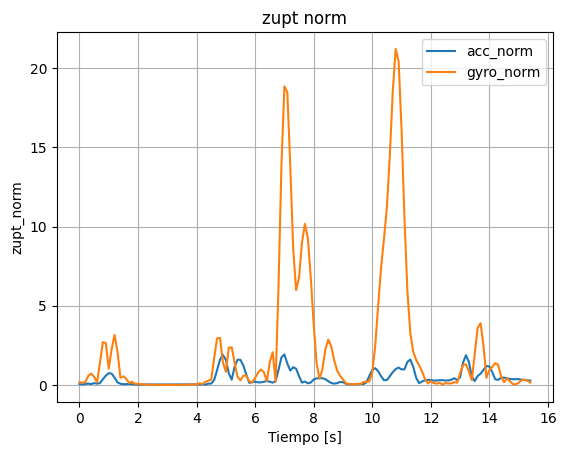

In [561]:
plt.figure()
plt.plot(t, df_u["acc_norm"], label="acc_norm")
plt.plot(t, df_u["gyro_norm"], label="gyro_norm")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_norm")
plt.legend()
plt.grid(True)
plt.title("zupt norm")
plt.show()

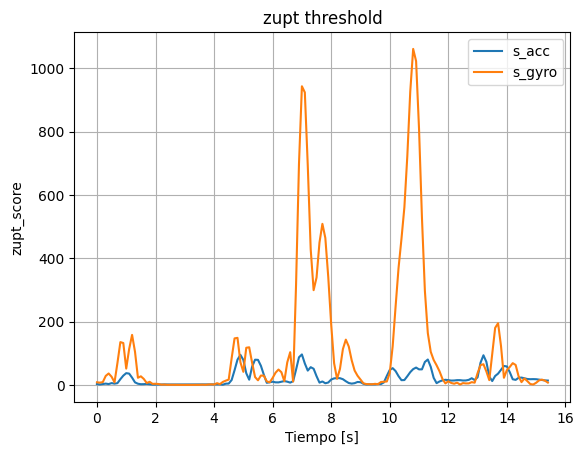

In [562]:
plt.figure()
plt.plot(t, df_u["s_acc"], label="s_acc")
plt.plot(t, df_u["s_gyro"], label="s_gyro")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_score")
plt.legend()
plt.grid(True)
plt.title("zupt threshold")
plt.show()

In [563]:
"""# 1. ZUPT DURO
if ||a|| < ACC_TH and ||ω|| < GYRO_TH:
    v = 0

# 2. ZUPT como realimentación
vk+1​ = vk ​− Kzupt​ vk​

# 3. Detector zupT continuo (sin umbral duro)
# 3.1 Metrica de reposo (score)
acc_norm  = np.linalg.norm(a_body)
gyro_norm = np.linalg.norm(g)

s_acc  = acc_norm  / ACC_TH
s_gyro = gyro_norm / GYRO_TH

zupt_score = max(s_acc, s_gyro)

# 3.2 Activacion suave (funcion logistica)
def smooth_step(x, x0=1.0, k=10.0):
    return 1.0 / (1.0 + np.exp(k*(x - x0)))

w_zupt = smooth_step(zupt_score) 
# w_zupt = 1 -> ZUPT fuerte
# w_zupt = 0 -> sin ZUPT

# 4 ZUPT suave con ganancia
K_zupt = 0.5 # ganancia ZUPT (tuneable)

v -= K_zupt * w_zupt * v

# 5 HNC suave (no holonómica bien hecha)
# 5.1 Pasar velocidad a body
v_body = R_nb.T @ v"""

'# 1. ZUPT DURO\nif ||a|| < ACC_TH and ||ω|| < GYRO_TH:\n    v = 0\n\n# 2. ZUPT como realimentación\nvk+1\u200b = vk \u200b− Kzupt\u200b vk\u200b\n\n# 3. Detector zupT continuo (sin umbral duro)\n# 3.1 Metrica de reposo (score)\nacc_norm  = np.linalg.norm(a_body)\ngyro_norm = np.linalg.norm(g)\n\ns_acc  = acc_norm  / ACC_TH\ns_gyro = gyro_norm / GYRO_TH\n\nzupt_score = max(s_acc, s_gyro)\n\n# 3.2 Activacion suave (funcion logistica)\ndef smooth_step(x, x0=1.0, k=10.0):\n    return 1.0 / (1.0 + np.exp(k*(x - x0)))\n\nw_zupt = smooth_step(zupt_score) \n# w_zupt = 1 -> ZUPT fuerte\n# w_zupt = 0 -> sin ZUPT\n\n# 4 ZUPT suave con ganancia\nK_zupt = 0.5 # ganancia ZUPT (tuneable)\n\nv -= K_zupt * w_zupt * v\n\n# 5 HNC suave (no holonómica bien hecha)\n# 5.1 Pasar velocidad a body\nv_body = R_nb.T @ v'

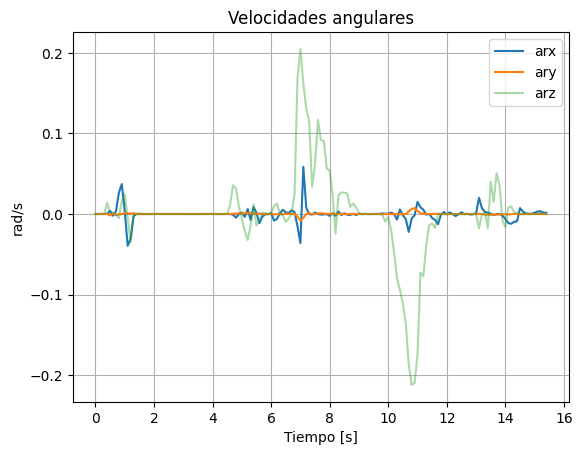

array([ 1.90624173e-05, -9.07869188e-04, -4.05747072e-04,  1.32435046e-03,
        1.94425040e-03, -5.27682380e-04, -3.35781839e-03,  5.71554035e-04,
        1.38260090e-02,  2.63202661e-02,  2.26382632e-02,  6.85286912e-04,
       -2.24145237e-02, -2.80378701e-02, -1.58193005e-02, -8.92975538e-04,
        4.75998197e-03,  2.18142393e-03, -1.21412717e-03, -1.52605605e-03,
       -9.86618928e-05,  6.88084185e-04,  3.77454532e-04, -1.29435968e-04,
       -2.13926345e-04, -2.16515377e-05,  9.24886470e-05,  4.32455504e-05,
       -3.62657643e-05, -4.85677512e-05, -1.77256245e-05, -7.74053725e-07,
       -7.02464294e-06, -9.45927762e-06,  6.61797296e-06,  2.57572290e-05,
        2.42649850e-05,  2.77657056e-06, -7.12135748e-06,  1.79036479e-05,
        4.33177722e-05, -1.10565945e-06, -1.07455126e-04, -1.24931947e-04,
        7.40685755e-05,  2.98010546e-04,  7.08976770e-05, -7.81679520e-04,
       -1.67491570e-03, -1.81669066e-03, -1.21697006e-03, -5.58844048e-04,
        2.30894622e-06,  

In [564]:
plt.figure()
plt.plot(t, df_u["arx"], label="arx")
plt.plot(t, df_u["ary"], label="ary")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz"], label="arz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares")
plt.show()

arx_f	

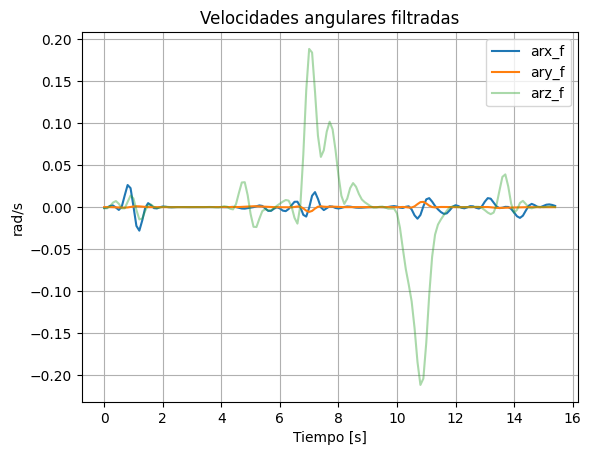

In [565]:
plt.figure()
plt.plot(t, df_u["arx_f"], label="arx_f")
plt.plot(t, df_u["ary_f"], label="ary_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz_f"], label="arz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares filtradas")
plt.show()

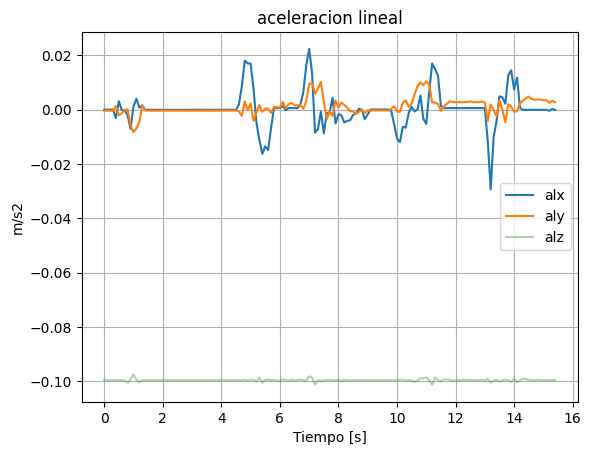

In [566]:
plt.figure()
plt.plot(t, df_u["alx"], label="alx")
plt.plot(t, df_u["aly"], label="aly")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz"], label="alz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

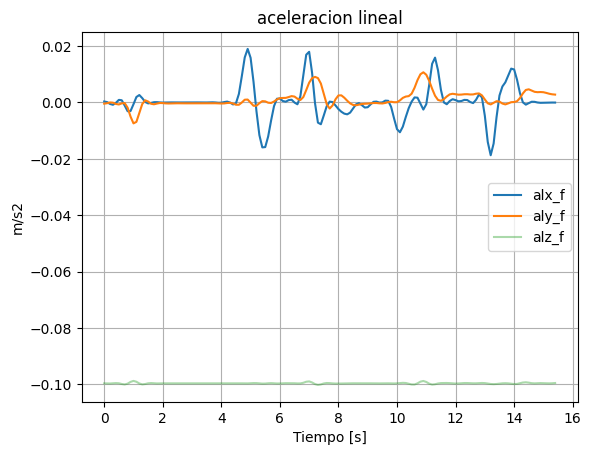

In [567]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="alx_f")
plt.plot(t, df_u["aly_f"], label="aly_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz_f"], label="alz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

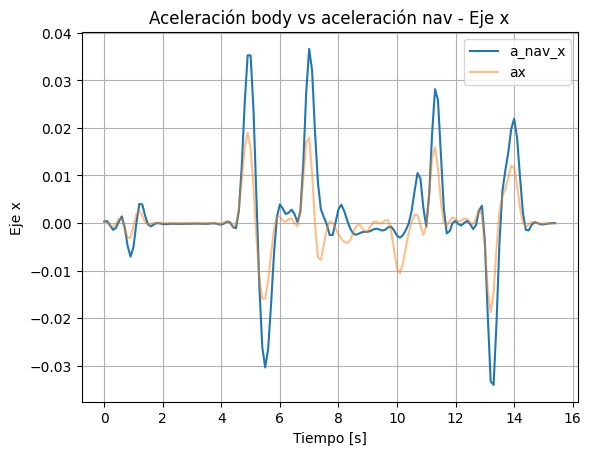

In [568]:
axi = "x"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

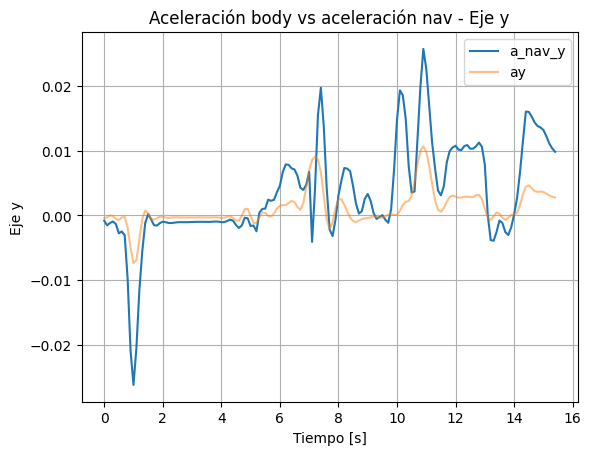

In [569]:
axi = "y"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

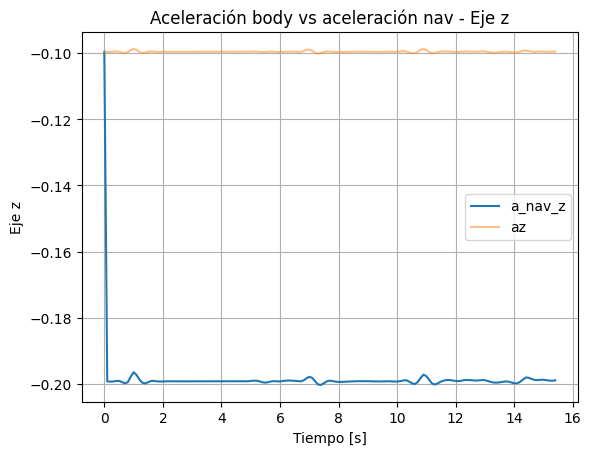

In [570]:
axi = "z"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

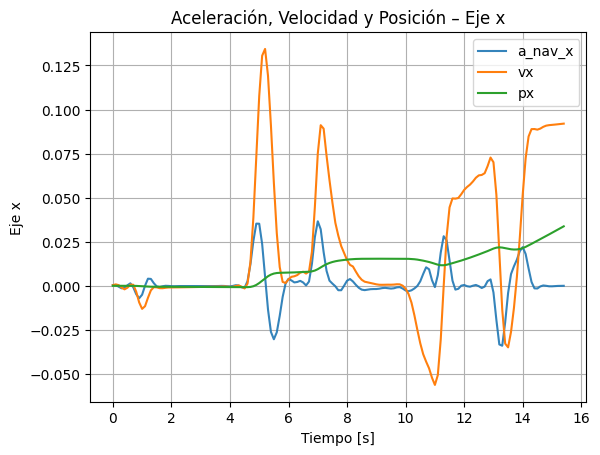

In [571]:
def plot_unEje_ac_v_p(axi):
    plt.figure()

    plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}", alpha=0.9)
    # plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)
    plt.title(f"Aceleración, Velocidad y Posición – Eje {axi}")
    plt.show()

plot_unEje_ac_v_p("x")

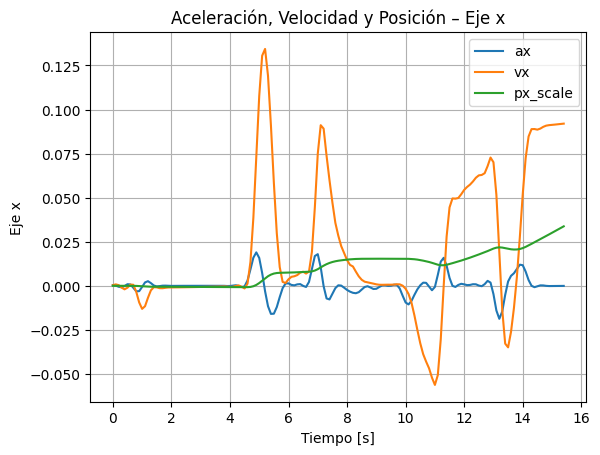

In [572]:
def plot_unEje_ac_v_p(axi):
    plt.figure()
    plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df_u[f"p{axi}_scale"], label=f"p{axi}_scale")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)
    plt.title(f"Aceleración, Velocidad y Posición – Eje {axi}")
    plt.show()

plot_unEje_ac_v_p("x")

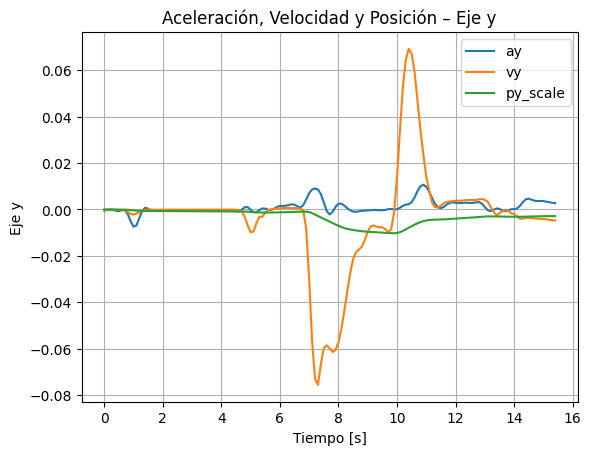

In [573]:
# import matplotlib as plt
# # def plot_unEje_ac_v_p():
# plt.figure()
# plt.plot(t, df_u["aly_f"], label="ay")
# plt.plot(t, df_u["vy"], label="vy")
# plt.plot(t, df_u["py"], label="py")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Y")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Y")
# plt.show()
# # plot_unEje_ac_v_p()

plot_unEje_ac_v_p("y")

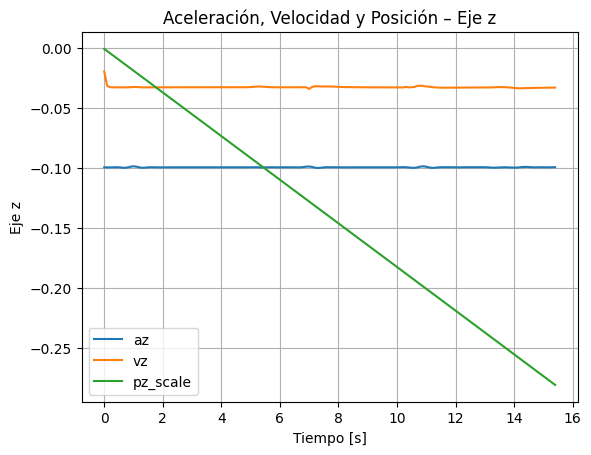

In [574]:
# import matplotlib as plt
# # def plot_unEje_ac_v_p():
# plt.figure()
# plt.plot(t, df_u["aly_f"], label="ay")
# plt.plot(t, df_u["vy"], label="vy")
# plt.plot(t, df_u["py"], label="py")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Y")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Y")
# plt.show()
# # plot_unEje_ac_v_p()

plot_unEje_ac_v_p("z")

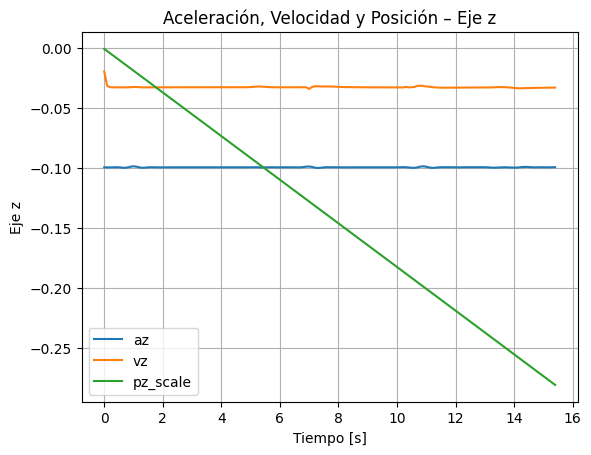

In [575]:
# plt.figure()
# plt.plot(t, df_u["alz_f"], label="az")
# plt.plot(t, df_u["vz"], label="vz")
# plt.plot(t, df_u["pz"], label="pz")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Z")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Z")
# plt.show()

plot_unEje_ac_v_p("z")

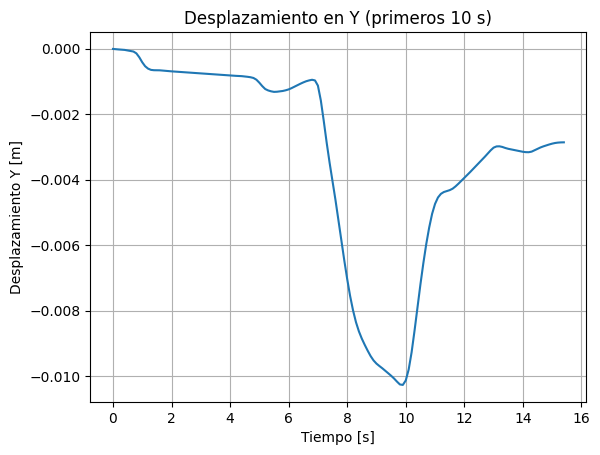

In [576]:
df_u["time_s"] = (df_u["time"] - df_u["time"].iloc[0]) * 1e-9
df_10s = df_u[df_u["time_s"] <= 300]
plt.figure()
plt.plot(df_10s["time_s"], df_10s["py_scale"])
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento Y [m]")
plt.title("Desplazamiento en Y (primeros 10 s)")
plt.grid(True)
plt.show()

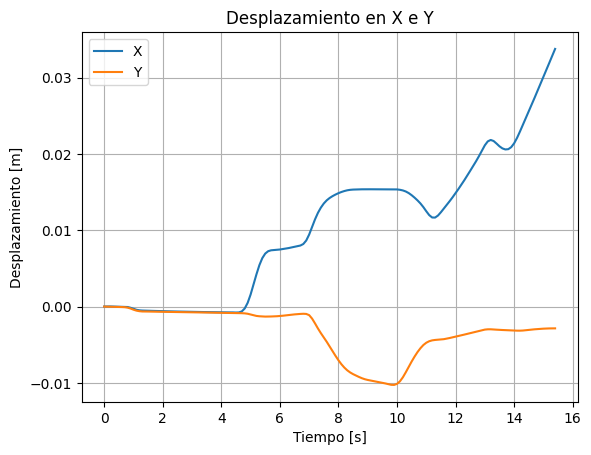

In [577]:
plt.figure()
plt.plot(df_10s["time_s"], df_10s["px_scale"], label="X")
plt.plot(df_10s["time_s"], df_10s["py_scale"], label="Y")

plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.title("Desplazamiento en X e Y")
plt.legend()
plt.grid(True)
plt.show()

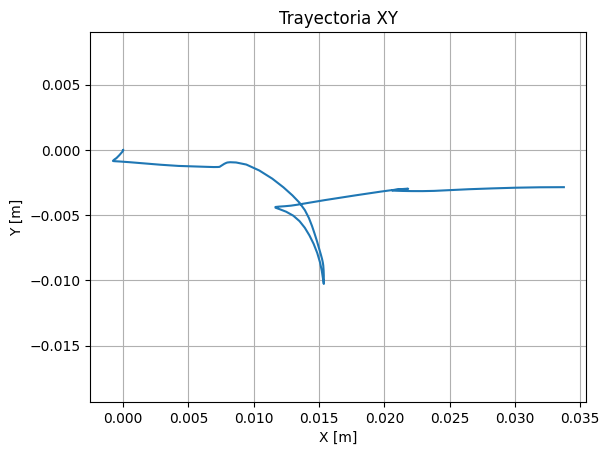

In [578]:
plt.figure()
plt.plot(df_10s["px_scale"], df_10s["py_scale"])
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Trayectoria XY")
plt.axis("equal")  # Importante para INS
plt.grid(True)
plt.show()

In [579]:
a = df_u.loc[5, ["alx", "aly", "alz"]].values
norm = np.linalg.norm(a)
a_norm = a / np.linalg.norm(a)
print(a)
print(norm)
print(a_norm)
print(a[0], abs(a[0]))

[ 0.00316135 -0.00203158 -0.09953217]
0.0996030861304099
[ 0.03173951 -0.02039679 -0.99928803]
0.0031613535247743 0.0031613535247743


In [580]:
def plot_unEje(df, axi, params, save_path):

    plt.figure()
    plt.plot(t, df[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df[f"p{axi}"], label=f"p{axi}")

    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    plt.title(title)
    plt.savefig(save_path)
    plt.close()

In [581]:
def plot_xyz(df, params, save_path):

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    ejes = ["x", "y", "z"]

    for i, axi in enumerate(ejes):

        axes[i].plot(t, df[f"al{axi}_f"], label=f"a{axi}")
        axes[i].plot(t, df[f"v{axi}"], label=f"v{axi}")
        axes[i].plot(t, df[f"p{axi}"], label=f"p{axi}")

        axes[i].set_ylabel(f"Eje {axi}")
        axes[i].grid(True)
        axes[i].legend()

    axes[2].set_xlabel("Tiempo [s]")

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(save_path)
    plt.close()

In [582]:
import os
import itertools

# ruta_resultados = "resultados2"

os.makedirs(ruta_resultados, exist_ok=True)

ACC_TH_vals = [0.144, 0.269] # [0.102, 0.144, 0.269, 0.353, 0.437]
GYRO_TH_vals = [0.011, 0.017] # [0.006, 0.011, 0.017, 0.022, 0.028]
ZUPT_GAIN_vals = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
SIGMOID_GAIN_vals = [1, 5, 10, 15, 20]

def ins_tuning():
    for ACC_TH, GYRO_TH, ZUPT_GAIN, SIG_GAIN in itertools.product(
            ACC_TH_vals,
            GYRO_TH_vals,
            ZUPT_GAIN_vals,
            SIGMOID_GAIN_vals):

        df_test = df_u.copy()

        ins(
            df_test,
            ACC_TH=ACC_TH,
            GYRO_TH=GYRO_TH,
            ZUPT_GAIN=ZUPT_GAIN,
            ZUPT_SIGMOID_GAIN=SIG_GAIN
        )

        params = {
            "ACC_TH": ACC_TH,
            "GYRO_TH": GYRO_TH,
            "ZUPT_GAIN": ZUPT_GAIN,
            "SIG_GAIN": SIG_GAIN
        }

        filename = f"{ruta_resultados}/A{ACC_TH}_G{GYRO_TH}_Z{ZUPT_GAIN}_S{SIG_GAIN}.png"
        
        plot_xyz(df_test, params, filename)

In [583]:
ins_tuning()

                    time        q0        q1        q2        q3       arx  \
0    1773427747770151936  0.999998  0.001999 -0.000074  0.000365  0.000041   
1    1773427747870151936  0.999998  0.001999 -0.000066  0.000367  0.000008   
2    1773427747970151936  0.999998  0.001998 -0.000076  0.000367  0.000007   
3    1773427748070151936  0.999998  0.002012 -0.000068  0.000379  0.000034   
4    1773427748170151680  0.999969  0.002177 -0.000084  0.007546  0.000354   
..                   ...       ...       ...       ...       ...       ...   
150  1773427762769497088  0.999421 -0.014996 -0.001638  0.030493  0.001527   
151  1773427762869364400  0.999442 -0.013417 -0.001450  0.030544  0.003223   
152  1773427762969364480  0.999440 -0.011805 -0.001288  0.031283  0.003320   
153  1773427763069364224  0.999436 -0.011018 -0.001142  0.031685  0.001718   
154  1773427763169364480  0.999442 -0.010361 -0.000998  0.031728  0.001480   

          ary       arz       alx       aly  ...        vx     

In [584]:
# # ZUPT parcial

# EPS_ACCEL = 0.1      # m/s^2
# VAR_ACCEL = 0.02     # (m/s^2)^2
# MIN_SAMPLES = int(1.0 * fs)

# zupt = np.zeros(len(accel_filt), dtype=bool)
# counter = 0

# for k in range(N, len(accel_filt)):
#     acc_win = accel_filt[k-N:k]
    
#     acc_var = np.mean(np.var(acc_win, axis=0))
#     acc_dev = abs(acc_norm[k] - g)

#     stationary = (
#         acc_dev < EPS_ACCEL and
#         acc_var < VAR_ACCEL
#     )

#     if stationary:
#         counter += 1
#         if counter >= MIN_SAMPLES:
#             zupt[k] = True
#     else:
#         counter = 0

In [585]:
# # magnitud total del ZUPT

# acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
# acc_mag_f = np.sqrt(ax_f**2 + ay_f**2 + az_f**2)

# plt.figure(figsize=(12,6))
# plt.plot(t, acc_mag, label='|a| original', alpha=0.4)
# plt.plot(t, acc_mag_f, label='|a| filtrado', linewidth=2)
# plt.axhline(9.81, color='k', linestyle='--', label='g')
# plt.legend()
# plt.grid()
# plt.title("Magnitud de aceleración")
# plt.show()

In [586]:
# Diseño de umbrales para ZUPT (criterio práctico)

# ZUPT no se diseña “a ojo”, se basa en:

# Aceleración cerca de g

# Baja varianza

# Giroscopio bajo (si lo tienes)

# Umbrales típicos (100 Hz)
# Variable	Umbral típico
# |a| − g	< 0.05 – 0.15 m/s²
# σ(a) ventana	< 0.02 – 0.05 m/s²
# |ω|	< 0.5 – 2 deg/s
# Ventana	0.2 – 0.5 s

In [587]:
# Eso es ingeniería bien hecha:

# FFT → identificar banda útil

# Allan → ruido y bias

# Datos reales → ajustar fc y umbrales

In [588]:
# from scipy.signal import sosfilt

# # gyro_filt = sosfilt(sos, gyro_raw)
# accel_filt = sosfilt(sos, accel_raw)

In [589]:
# from scipy.signal import sosfiltfilt

# gyro_filt = sosfiltfilt(sos, gyro_raw)